In [1]:
print("hello")

hello


In [12]:
import pandas as pd
import mysql.connector
import numpy as np

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
     ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments') ,
    ('order_items.csv','order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='12345',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/HP/Desktop/Ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install numpy


Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install mysql-connector-python

   ---------------------------------------- 0.0/16.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.1 MB ? eta -:--:--
    --------------------------------------- 0.3/16.1 MB ? eta -:--:--
   - -------------------------------------- 0.8/16.1 MB 1.9 MB/s eta 0:00:09
   --- ------------------------------------ 1.3/16.1 MB 2.0 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/16.1 MB 2.1 MB/s eta 0:00:07
   ----- ---------------------------------- 2.4/16.1 MB 2.2 MB/s eta 0:00:07
   ------- -------------------------------- 2.9/16.1 MB 2.2 MB/s eta 0:00:07
   ------- -------------------------------- 3.1/16.1 MB 2.2 MB/s eta 0:00:06
   --------- ------------------------------ 3.7/16.1 MB 2.2 MB/s eta 0:00:06
   ----------- ---------------------------- 4.5/16.1 MB 2.2 MB/s eta 0:00:06
   ------------ --------------------------- 5.0/16.1 MB 2.2 MB/s eta 0:00:05
   ------------- -------------------------- 5.2/16.1 MB 2.2 MB/s eta 0:00:05
   -------------- --

In [6]:
pip install matplotlib



   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.0 MB 5.3 MB/s eta 0:00:02
   ------------- -------------------------- 2.6/8.0 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 3.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 3.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 2.9 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.0 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 3.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 2.9 MB/s eta 0:00:00
   ---------------

In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np

db = mysql.connector.connect(
    host = "localhost",
    username = "root",
    password = "12345",
    database= "ecommerce"
    
    
)
cur = db.cursor()


In [28]:
# Q = List all Unique Cities where customers are located

query = """ select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data)
df.head()


,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


In [7]:
# Q = count the number of order placed in 2017

query = """ select count(order_id) from orders where year(order_purchase_timestamp) =2017  """

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

print('total order places in 2017 =',data[0][0])


total order places in 2017 = 180404


In [16]:
# Q = Find total Sa;e per category

query = """ select products.product_category category,round(sum(payments.payment_value),2) sales
from products join order_items
on products.product_id = order_items.product_id  
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data, columns= ["Category","Sales"])



,Category,Sales
0,perfumery,4560647.94
1,Furniture Decoration,12871587.53
2,telephony,4381938.46
3,bed table bath,15412983.04
4,automotive,7670648.98
...,...,...
69,cds music dvds,10794.87
70,La Cuisine,26221.77
71,Fashion Children's Clothing,7071.03
72,PC Gamer,19569.87


In [20]:
# Q = Calculate the percentage of order that were paid by installments

query = """ select (sum(case when payment_installments >= 1 then 1 else 0 end))/count(*)*100 from payments
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

print('percentage of order paid by installment',data [0][0])

percentage of order paid by installment 99.9981


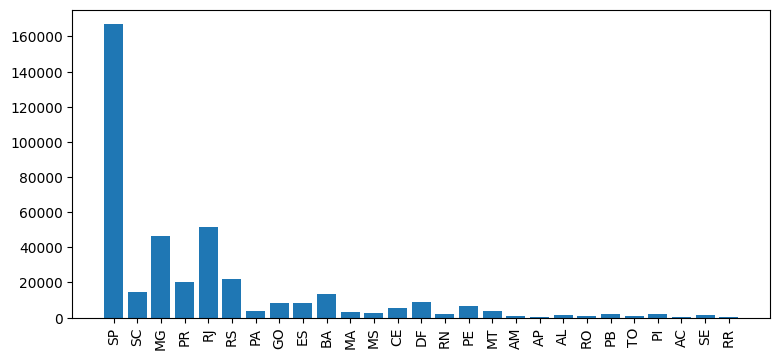

In [26]:
# Q = Count the number of customer each state

query = """ select customer_state,count(customer_id) from customers group by customer_state
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data,columns = ['State','customer_count'])

plt.figure(figsize=(9,4))
plt.bar(df["State"],df["customer_count"])
plt.xticks(rotation =90)
plt.show()

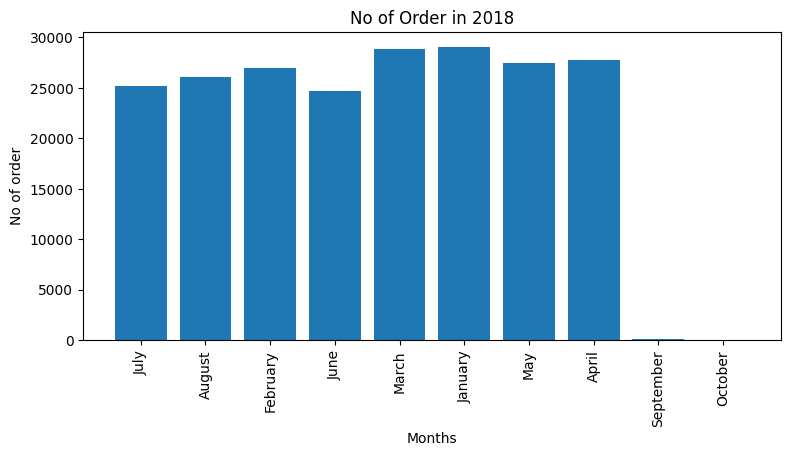

In [42]:
# Q = Calculate the number of order permonth in 2018
query = """ select monthname(order_purchase_timestamp) months ,count(order_id) order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data ,columns = ["Months","No of order"])

plt.figure(figsize=(9,4))
plt.bar(df["Months"],df["No of order"])
plt.xticks(rotation =90)
plt.xlabel("Months")
plt.ylabel("No of order")
plt.title("No of Order in 2018")
plt.show()


In [50]:
# Q = AVERAGE ORDER  ON THE BASIS OF CUSTOMER CITY

query = """with count_per_order as
(select orders.order_id,orders.customer_id,count(order_items.order_id)as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id,orders.customer_id)

select customers.customer_city,avg(count_per_order.oc) avg_order
from customers join count_per_order
on customers.customer_id=count_per_order.customer_id  
group by customers.customer_city order by avg_order

"""

cur.execute(query)

data = cur.fetchall() 
df = pd.DataFrame(data,columns=["customer_city","avg_order"])
df.head(10)




,customer_city,avg_order
0,campo alegre de minas,4.0000
1,manfrinopolis,4.0000
2,ulianopolis,4.0000
3,adustina,4.0000
4,patrocinio paulista,4.0000
5,perpetuo socorro,4.0000
6,santa maria do salto,4.0000
7,abatia,4.0000
8,pontalinda,4.0000
9,capitao andrade,4.0000


In [54]:
# Q = total revenue each product category

query = """ select (products.product_category) category,
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id  
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data, columns= ["category","sales_percentage"])
df.head(5)

,category,sales_percentage
0,bed table bath,32.09
1,HEALTH BEAUTY,31.06
2,computer accessories,29.71
3,Furniture Decoration,26.80
4,Watches present,26.78


In [61]:

# Q = Identify the correlation between product price and the number of times a product has been purchased.


query = """ select products.product_category,
count(order_items.product_id) , round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category;
"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here

df = pd.DataFrame(data, columns= ["product_category","order_count","price"])


arr1 = df["order_count"]
arr2 = df["price"]
np.corrcoef([arr1,arr2])


array([[ 1.        , -0.10631514],
       [-0.10631514,  1.        ]])

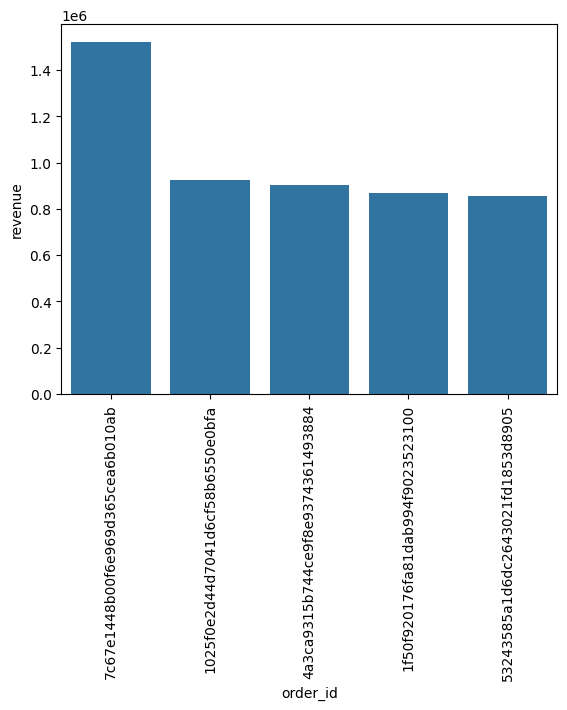

In [4]:
# Q= calculate revenue generated by each seller and rank them accordingly

query = """ select * ,dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id ,sum(payments.payment_value)
revenue from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a 

"""

cur.execute(query)

data = cur.fetchall()  # Add parentheses here
df = pd.DataFrame(data, columns= ["order_id","revenue","rank"])
df= df.head()

sns.barplot(x = "order_id" , y = "revenue",data = df)
plt.xticks(rotation = 90)
plt.show()

